In [43]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [73]:
class GDRegressor:
    def __init__(self,learning_rate=0.01,epochs=100):
        self.intercept=None
        self.coef=None
        self.lr=learning_rate
        self.epochs=epochs
        self.loss_history=[]

    def fit(self,X_train,y_train):
        self.intercept=0
        self.coef=np.ones(X_train.shape[1])
        for i in range (self.epochs):
            
            for j in range(X_train.shape[0]):
                # Randomly selct an idx
                idx=np.random.randint(0,X_train.shape[0])
                # Predict  for single value
                y_hat=np.dot(X_train[idx],self.coef)+self.intercept
                # calculate the gradient of intercept(no mean single value)
                intercept_der=-2*(y_train[idx]-y_hat)
                # udate the intercept
                self.intercept=self.intercept-(self.lr*intercept_der)

                #calculate the intercept gradient no mean single value
                coef_der=-2*np.dot((y_train[idx]-y_hat),X_train[idx])
                
                # update the coef
                self.coef=self.coef-(self.lr*coef_der)

            # Calculate loss after each epoch
            y_pred = np.dot(X_train, self.coef) + self.intercept
            loss = np.mean((y_train - y_pred) ** 2)

            self.loss_history.append(loss)

        print(f'Intercept:{self.intercept}')
        print(f'Corfficients:{self.coef}')

    def predict(self,X_test):
        return np.dot(X_test,self.coef)+self.intercept

                
                
                

In [74]:
from sklearn.datasets import load_diabetes

# Load the dataset
X, y = load_diabetes(return_X_y=True)

print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [75]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [76]:
# Compare with sklearn's LinearRegression
sklearn_SDGreg = SGDRegressor(learning_rate=0.01,max_iter=40)
sklearn_reg.fit(X_train, y_train)

print(f"\nSklearn Coefficients: {sklearn_reg.coef_}")
print(f"Sklearn Intercept: {sklearn_reg.intercept_}")

sklearn_pred = sklearn_reg.predict(X_test)
print(f"Sklearn R² Score: {r2_score(y_test, sklearn_pred)}")


Sklearn Coefficients: [  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
Sklearn Intercept: 151.88331005254167
Sklearn R² Score: 0.4399338661568968


In [99]:
# Our Gradient Descent Implementation
gd_reg = GDRegressor(learning_rate=0.1,epochs=40)
gd_reg.fit(X_train, y_train)

gd_pred = gd_reg.predict(X_test)
print(f"\nGD Regressor R² Score: {r2_score(y_test, gd_pred)}")

Intercept:149.76889667116012
Corfficients:[ -16.2357759  -179.78181404  526.50587796  331.57512624  -82.18708204
 -120.28840369 -189.70042652   80.95822747  509.02776448   81.21789392]

GD Regressor R² Score: 0.44584481472770265


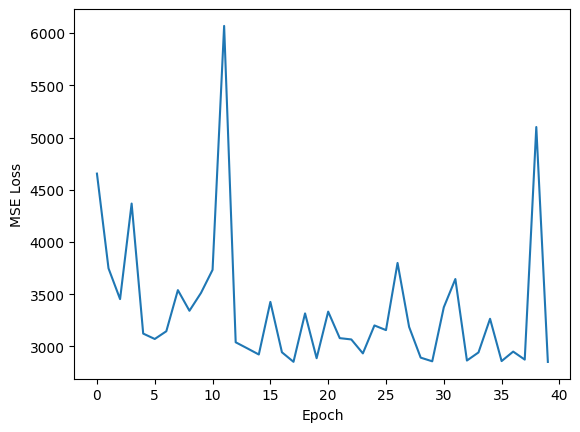

In [103]:
import matplotlib.pyplot as plt

plt.plot(gd_reg.loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()